### Exploratory Data Analysis: Student Habits & Academic Performance

- 5 Questions about Univariate Analysis
- 5 Questions about Bivariate Analysis

In [ ]:
# --imports both ggplot2 and dplyr
library(tidyverse)

# load dataset
data <- read.csv("https://raw.githubusercontent.com/leiandrei/exploratory-data-analysis/main/data/enhanced_student_habits_performance_dataset.csv")
head(data)

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,⋯,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<dbl>,<int>
1,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,⋯,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
2,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,⋯,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
3,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,⋯,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
4,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,⋯,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
5,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,⋯,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98
6,100005,17,Female,Engineering,4.200000,0.5,2.5,No,49.2,9.2,⋯,8.9,Quiet Room,No,High,1,10,5,Visual,3.9,94


#### **Univariate Question:** Determine the distribution of mental health rating of students accross the data. In addition, is the distribution skewed, normal or bimodal? **(LEI)**

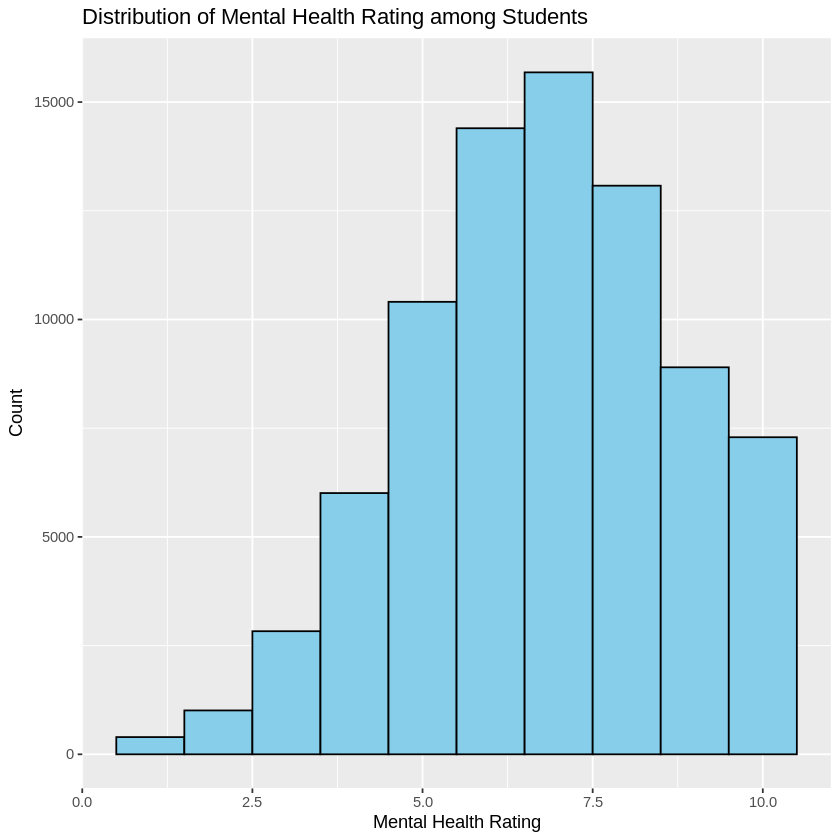

In [ ]:
ggplot(data, aes(mental_health_rating)) +
    geom_histogram(fill = "skyblue", color = "black", binwidth = 1) +
    labs(title = "Distribution of Mental Health Rating among Students", x = "Mental Health Rating", y = "Count")

##### **Interpretation:** The histogram plot was used to show the distribution of mental health ratings of the students. The distribution shows that the extreme values are more seated in between (5.0 and 7.5). Moreover, the distribution of the data is shows a unimodal, slightly left-skewed distribution as some values are less frequent to appear between (1 to 4). Therefore, the data shows that most students tend to report a moderate to high mental health ratings.

#### **Bivariate Question:** How does the gender influence the choice of academic major, and which disciplines in academics are more heavily populated by one gender than the other? **(LEI)**

In [ ]:
# --table count for all genders across majors--
genders_majors <- data %>%
  group_by(major, gender) %>%
  summarize(genderCount = n(), .groups = "drop")

# --table count for males--
male_majors <- data %>%
    filter(gender == "Male") %>%
    group_by(major) %>%
    summarize(genderCount = n(), .groups = "drop")

# -- table count for females--
female_majors <- data %>%
  filter(gender == "Female") %>%
  group_by(major) %>%
  summarize(genderCount = n(), .groups = "drop")

# -- table count for other genders--
others <- data %>%
  filter(gender == "Other") %>%
  group_by(major) %>%
  summarize(genderCount = n(), .groups = "drop")

In [ ]:
genders_majors

major,gender,genderCount
<chr>,<chr>,<int>
Arts,Female,4594
Arts,Male,4407
Arts,Other,4504
Biology,Female,4378
Biology,Male,4406
Biology,Other,4417
Business,Female,4525
Business,Male,4390
Business,Other,4361


In [ ]:
male_majors

major,genderCount
<chr>,<int>
Arts,4407
Biology,4406
Business,4390
Computer Science,4527
Engineering,4393
Psychology,4575


In [ ]:
female_majors

major,genderCount
<chr>,<int>
Arts,4594
Biology,4378
Business,4525
Computer Science,4337
Engineering,4417
Psychology,4454


In [ ]:
others

major,genderCount
<chr>,<int>
Arts,4504
Biology,4417
Business,4361
Computer Science,4488
Engineering,4419
Psychology,4408


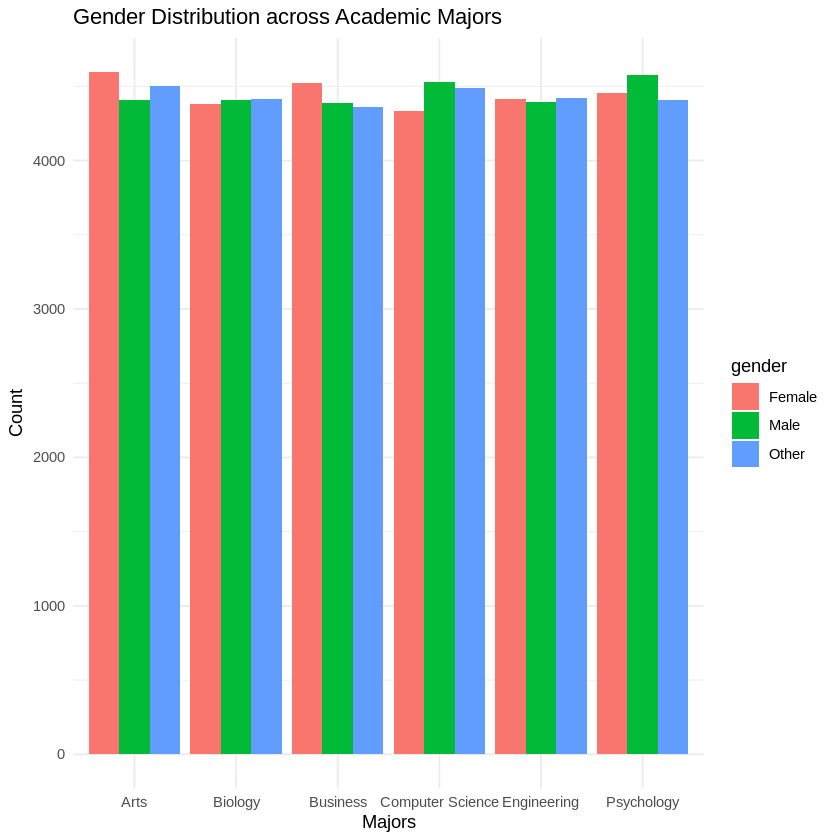

In [ ]:
# -- data visualization: grouped bar chart
ggplot(genders_majors, aes(major, genderCount, fill=gender)) +
  geom_col(position = "dodge") + theme_minimal() + labs(
  title = "Gender Distribution across Academic Majors",
  x="Majors", y="Count"
  )

##### **Interpretation:** Using the Horizontal Grouped Bar Chart to determine the distribution of genders across different academic disciplines. The distribution shows that the majority of the Male students tend to major at Computer Science and Pyschology. Conversely, Business appears to be the least common major among male respondents

##### On the other hand, majority of the female students alongside with other genders tends to represent the Arts and Business discipline more. Moreover, the distribution shows that the gender distribution is slightly balanced when it comes on majoring in Engineering.

##### In conclusion, the results suggest that the gender might correlate with the choice of academic majors, with clusters forming between STEM and Arts, while Engineering will remain as the most gender balanced discipline.

#### **Univariate Question:** Within what range of hours is the majority of student screen time concentrated? **(Justin)**

In [ ]:
data %>%
  ggplot(aes(x = screen_time)) +
  geom_histogram(binwidth = 0.5, fill = "orange", color = "white") +
  labs(title = "Histogram of Daily Screen Time", x = "Screen Time (hours)", y = "Number of Students") +
  theme_minimal()



**Interpretation:** The histogram reveals a symmetric, bell-shaped distribution centered at 10 hours, which specifically shows that the majority of student screen time is concentrated between 8 and 12 hours daily. This tight gathering of observations indicates that staying within this particular four-hour range is a standard routine for the vast majority of the group, with very few individuals falling into the extreme low or high categories as outliers. Because the data is so densely packed within this specific interval around the center, it shows that digital consumption is a remarkably consistent and shared characteristic of the students' daily lives rather than a scattered or random habit.

In conclusion, the high concentration of data within this 8-to-12 hour range confirms that high daily device usage is a very common and uniform routine for almost every student in this dataset.
